# AutoencoderKL Understanding
Following notebook aims to understand the missunderstanding we've had in regards to the latent space encoding of an image. From our experience, the encoding returns a distribution and then samples from it. We want it to be deterministic.

In [1]:
import os
from diffusers import AutoencoderKL
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


local_model_path = "/media/aris/Data/master2025dev/aris_master/models/VAE/vae-ft-mse-840000-ema-pruned"
print("Loading VAE model from:", local_model_path)
vae = AutoencoderKL.from_pretrained(local_model_path)
vae.to(device)

img_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories/train/impregnated_wood/images/img_bold-eagle_2024-11-04T16-33-09-968.png"
from PIL import Image
image = Image.open(img_path).convert("RGB")

#convert image to tensor
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
image = transform(image).unsqueeze(0).to(device)

def plot_image(tensor, title="Image"):
    import matplotlib.pyplot as plt
    tensor = tensor.squeeze(0).cpu()
    tensor = (tensor * 0.5) + 0.5  # Denormalize
    np_image = tensor.permute(1, 2, 0).numpy()
    plt.imshow(np_image)
    plt.title(title)
    plt.axis('off')
    plt.show()
    

with torch.no_grad():
    latents = vae.encode(image)[0]
    print("Latent shape:", latents.sample().shape)

# save latents to disk
save_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories/train/impregnated_wood/test_latent.pt"
# torch.save(latents.sample().cpu(), save_path)

    

/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading VAE model from: /media/aris/Data/master2025dev/aris_master/models/VAE/vae-ft-mse-840000-ema-pruned
Latent shape: torch.Size([1, 4, 16, 16])


Loaded latent shape: torch.Size([1, 4, 16, 16])


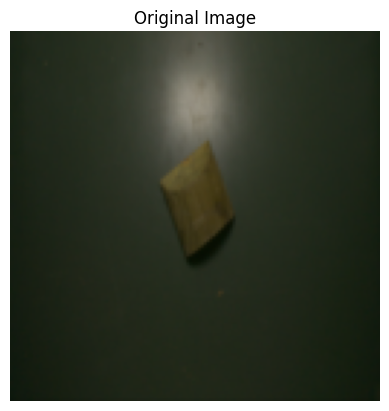

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.006629169..0.5877109].


Decoded image shape: torch.Size([1, 3, 128, 128])


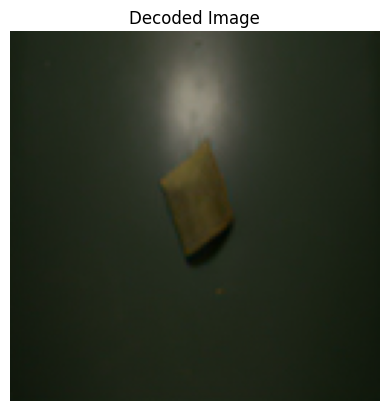

In [10]:
#load latents from disk
load_path = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories/train/impregnated_wood/latents_128/img_bold-eagle_2024-11-04T16-33-09-968.pt"
loaded_latents = torch.load(load_path).to(device).unsqueeze(0) / vae.config.scaling_factor
print("Loaded latent shape:", loaded_latents.shape)

plot_image(image, title="Original Image")

with torch.no_grad():
    decoded_image = vae.decode(loaded_latents, return_dict=False)[0]
    print("Decoded image shape:", decoded_image.shape)
plot_image(decoded_image, title="Decoded Image")